In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
gdf = gpd.read_parquet('data/blocks_indicator.parquet').to_crs(32636)
gdf = gdf.fillna(0)
gdf.head()

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Группы признаков
groups = {
    "Демография и урбанизация": [
        'Численность населения', 'Степень урбанизации территории'
    ],
    "Транспортная доступность": [
        'Средняя доступность до федеральных транспортных магистралей',
        'Средняя доступность до центра региона',
        'Средняя доступность  автозаправочных станций',
        'Средняя доступность остановок железнодорожного транспорта',
        'Средняя доступность международных аэропортов',
        'Средняя доступность аэропортов местного значения',
    ],
    "Дорожная инфраструктура": [
        'Плотность улично-дорожной сети',
        'Протяженность дорог федерального значения',
        'Протяженность дорог регионального значения',
        'Протяженность дорог местного значения',
        'Количество остановок общественного транспорта',
        'Количество остановок железнодорожного транспорта',
        'Связанность',
        'Связанность населенных пунктов',
        'Связанность общественным транспортом'
    ],
    "Транспорт и автомобили": [
        'Количество автозаправочных станций',
        'Обеспеченность автозаправками',
        'Обеспеченность парковками',
        'Обеспеченность ЖД станциями',
        'Обеспеченность автосалонами / автосервисами'
    ],
    "Соц. инфраструктура": [
        'Обеспеченность детскими садами', 'Обеспеченность школами',
        'Обеспеченность центрами детского творчества',
        'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками',
        'Обеспеченность поликлиниками / центрами семейной медицины',
        'Обеспеченность участковыми больницами',
        'Обеспеченность городскими больницами (д/в)',
        'Обеспеченность коммерческими клиниками'
    ],
    "Коммерция": [
        'Обеспеченность продуктовыми магазинами',
        'Обеспеченность ТЦ / супермаркетами',
        'Обеспеченность зоомагазинами',
        'Обеспеченность ТРК / гипермаркетами',
        'Обеспеченность кафе / кофейнями',
        'Обеспеченность барами / ресторанами',
        'Обеспеченность пунктами доставки / почтовыми отделениями',
        'Обеспеченность парикмахерскими / салонами красоты',
        'Обеспеченность отделениями банков'
    ],
    "Общественные объекты": [
        'Обеспеченность комьюнити-центрами / домами культуры',
        'Обеспеченность культовыми объектами',
        'Обеспеченность участковыми пунктами полиции',
        'Обеспеченность опорными пунктами полиции',
        'Обеспеченность пожарными депо'
    ],
    "Рекреация и спорт": [
        'Обеспеченность детскими площадками',
        'Обеспеченность скверами / бульварами / лесопарками',
        'Обеспеченность парками',
        'Обеспеченность воркаутами / школьными спортзалами',
        'Обеспеченность спортзалами ОП / фитнес-центрами',
        'Обеспеченность ФОК / бассейнами'
    ]
}

# Копируем gdf, исключая geometry
df = gdf.drop(columns=['geometry']).copy()

# Результаты по группам
group_indicators = pd.DataFrame()
group_indicators['id'] = df['id']

# Нормализация и агрегация по группам
scaler = MinMaxScaler()

for group_name, columns in groups.items():
    # Убираем колонки, которых нет в gdf (на всякий случай)
    cols_present = [col for col in columns if col in df.columns]
    if not cols_present:
        continue

    # Масштабируем значения
    scaled = scaler.fit_transform(df[cols_present].fillna(0))
    
    # Считаем среднее значение по группе
    group_indicators[group_name] = scaled.mean(axis=1).round(2)

# Выбираем основные идентификаторы из оригинального GeoDataFrame
id_columns = ['id', 'territory_id', 'name', 'geometry']
identifiers = gdf[id_columns].copy()

# Объединяем с рассчитанными групповыми индикаторами по 'id'
gdf_grouped = identifiers.merge(group_indicators, on='id')
gdf_grouped["Площадь"] = gdf_grouped.geometry.area.round(2)
# gdf_grouped теперь содержит все нужные поля
gdf_grouped


,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,1373078.24
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,770.93
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,604.07
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,45192.86
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,198.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,34645,1267.0,город Сосновый бор,"POLYGON ((279466.739 6647657.982, 279466.837 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,326840.45
34643,34646,1267.0,город Сосновый бор,"POLYGON ((279467.148 6647660.126, 279467.165 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,46770.80
34644,34647,1267.0,город Сосновый бор,"POLYGON ((279542.296 6648001.072, 279542.336 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16349.18
34645,34648,1267.0,город Сосновый бор,"POLYGON ((279625.847 6648207.164, 279625.886 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27188.68


In [4]:
territory_gdf = gpd.read_file('data/level_4_territories.geojson').to_crs(32636)
territory_gdf

,territory_id,territory_type,parent,name,level,properties,admin_center,target_city_type,okato_code,oktmo_code,is_city,created_at,updated_at,geometry
0,3,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Самойловское сельское поселение,4,"{ ""Численность населения"": 2154, ""Администрати...","{ ""id"": 310, ""name"": ""поселок Совхозный"" }",None,41203876000,41603476,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:52.704000+00:00,"POLYGON ((580049.515 6617067.72, 580225.344 66..."
1,4,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Большедворское сельское поселение,4,"{ ""Численность населения"": 1698, ""Администрати...","{ ""id"": 427, ""name"": ""деревня Большой Двор"" }",None,41203812000,41603412,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.396000+00:00,"POLYGON ((573514.444 6620389.851, 573579.919 6..."
2,5,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Пикалевское городское поселение,4,"{ ""Численность населения"": 20169, ""Администрат...","{ ""id"": 335, ""name"": ""город Пикалево"" }",None,41440000000,41603102,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.930000+00:00,"POLYGON ((564707.328 6594903.594, 564341.814 6..."
3,6,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Борское сельское поселение,4,"{ ""Численность населения"": 3393, ""Администрати...","{ ""id"": 2859, ""name"": ""деревня Бор"" }",None,41203816000,41603416,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:35.368000+00:00,"POLYGON ((560629.509 6557332.762, 560642.857 6..."
4,7,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Бокситогорское городское поселение,4,"{ ""Численность населения"": 15960, ""Администрат...","{ ""id"": 328, ""name"": ""город Бокситогорск"" }",None,41403000000,41603101,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:36.351000+00:00,"POLYGON ((560659.317 6585430.874, 559919.213 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,204,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Красноборское городское поселение,4,"{ ""Численность населения"": 4507, ""Администрати...","{ ""id"": 3072, ""name"": ""городской поселок Красн...",None,41248554000,41648154,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:09.784000+00:00,"POLYGON ((363803.737 6614904.469, 363821.597 6..."
185,205,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Трубникоборское сельское поселение,4,"{ ""Численность населения"": 1620, ""Администрати...","{ ""id"": 3122, ""name"": ""деревня Трубников Бор"" }",None,41248844000,41648444,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:10.264000+00:00,"POLYGON ((392924.072 6551507.217, 393174.409 6..."
186,206,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 193, ""name"": ""Тосненский муниципальный...",Лисинское сельское поселение,4,"{ ""Численность населения"": 1919, ""Администрати...","{ ""id"": 3095, ""name"": ""поселок Лисино-Корпус"" }",None,41248830000,41648430,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:19:25.346000+00:00,"POLYGON ((363959.223 6596385.107, 364013.066 6..."
187,1267,"{ ""id"": 4, ""name"": ""Город"" }","{ ""id"": 182, ""name"": ""Сосновоборский городской...",город Сосновый бор,4,{ },None,None,41454000000,41754000001,True,2024-06-16 21:35:40.802000+00:00,2024-11-29 11:31:30.081000+00:00,"POLYGON ((283435.008 6647206.979, 283361.394 6..."


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# 1. Статистика по исходным признакам (исключая идентификаторы и geometry)
exclude_cols = ['id', 'territory_id', 'name', 'geometry']

# 2. Статистика по агрегированным группам (из предыдущего шага)
group_stats = group_indicators.drop(columns=['id']).copy()

# Функция для расширенной статистики
def extended_stats(df):
    stats = df.describe().T
    # stats['median'] = df.median()
    # stats['range'] = df.max() - df.min()
    # stats['skewness'] = df.skew()
    # stats['kurtosis'] = df.kurtosis()
    # stats['missing_%'] = df.isna().mean() * 100
    return stats

# Получаем статистики

group_indicator_stats = extended_stats(group_stats)

print("\n📊 Статистика по группам индикаторов:")
display(group_indicator_stats)


📊 Статистика по группам индикаторов:


,count,mean,std,min,25%,50%,75%,max
Демография и урбанизация,34647.0,0.277003,0.152619,0.0,0.15,0.28,0.37,0.70
Транспортная доступность,34647.0,0.234270,0.125445,0.0,0.14,0.20,0.32,0.75
Дорожная инфраструктура,34647.0,0.246914,0.093474,0.0,0.17,0.23,0.31,0.45
Транспорт и автомобили,34647.0,0.574500,0.158794,0.0,0.48,0.60,0.69,0.89
Соц. инфраструктура,34647.0,0.638044,0.153837,0.0,0.53,0.66,0.75,1.00
Коммерция,34647.0,0.668546,0.200476,0.0,0.53,0.72,0.81,0.98
Общественные объекты,34647.0,0.493765,0.151287,0.0,0.40,0.47,0.60,0.91
Рекреация и спорт,34647.0,0.568960,0.218677,0.0,0.41,0.58,0.72,1.00


In [6]:
import json

# Убедимся, что parent — это словарь (если он закодирован как строка — преобразуем)
def extract_parent_name(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except json.JSONDecodeError:
            return None
    if isinstance(x, dict):
        return x.get("name")
    return None

def extract_parent_id(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except json.JSONDecodeError:
            return None
    if isinstance(x, dict):
        return x.get("id")
    return None

# Создаём вспомогательный DataFrame
parent_df = territory_gdf[['name', 'parent']].copy()
parent_df['parent_name'] = parent_df['parent'].apply(extract_parent_name)
parent_df['parent_territory_id'] = parent_df['parent'].apply(extract_parent_id)

# Оставим только нужные колонки
parent_df = parent_df[['name', 'parent_name', 'parent_territory_id']]

# Мёржим с gdf_grouped
gdf_grouped = gdf_grouped.merge(parent_df, on='name', how='left')
gdf_grouped

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,1373078.24,Бокситогорский муниципальный район,2
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,770.93,Бокситогорский муниципальный район,2
2,2,3.0,Самойловское сельское поселение,"POLYGON ((572676.73 6596606.982, 572676.701 65...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,604.07,Бокситогорский муниципальный район,2
3,3,3.0,Самойловское сельское поселение,"POLYGON ((583242.895 6595451.954, 583243.013 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,45192.86,Бокситогорский муниципальный район,2
4,4,3.0,Самойловское сельское поселение,"POLYGON ((582405.498 6595459.455, 582405.614 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,198.30,Бокситогорский муниципальный район,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34935,34645,1267.0,город Сосновый бор,"POLYGON ((279466.739 6647657.982, 279466.837 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,326840.45,Сосновоборский городской округ,182
34936,34646,1267.0,город Сосновый бор,"POLYGON ((279467.148 6647660.126, 279467.165 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,46770.80,Сосновоборский городской округ,182
34937,34647,1267.0,город Сосновый бор,"POLYGON ((279542.296 6648001.072, 279542.336 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16349.18,Сосновоборский городской округ,182
34938,34648,1267.0,город Сосновый бор,"POLYGON ((279625.847 6648207.164, 279625.886 6...",0.64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27188.68,Сосновоборский городской округ,182


In [7]:
# Шаг 1 — копируем оригинальный GeoDataFrame
gdf_grouped1 = gdf_grouped.copy()

# Шаг 2 — список колонок с нормализованными показателями
indicator_columns = [
    "Демография и урбанизация",
    "Транспортная доступность",
    "Дорожная инфраструктура",
    "Транспорт и автомобили",
    "Соц. инфраструктура",
    "Коммерция",
    "Общественные объекты",
    "Рекреация и спорт"
]

# Шаг 3 — расчёт "коэффициента качества" как среднего по нормализованным группам
gdf_grouped1["Индекс развития территории"] = gdf_grouped1[indicator_columns].mean(axis=1).round(2)
gdf_grouped1.head(2)

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id,Индекс развития территории
0,0,3.0,Самойловское сельское поселение,"POLYGON ((570883.045 6596529.946, 570883.081 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,1373078.24,Бокситогорский муниципальный район,2,0.28
1,1,3.0,Самойловское сельское поселение,"POLYGON ((570987.035 6596464.499, 570987.085 6...",0.13,0.42,0.21,0.26,0.39,0.35,0.31,0.19,770.93,Бокситогорский муниципальный район,2,0.28


In [8]:
filtered_gdf = gdf_grouped1[gdf_grouped1['parent_name'] == 'Сланцевский муниципальный район']
filtered_gdf.head(2)

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id,Индекс развития территории
1121,1070,175.0,Старопольское сельское поселение,"POLYGON ((270977.492 6561981.407, 270977.537 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,635.94,Сланцевский муниципальный район,174,0.3
1122,1071,175.0,Старопольское сельское поселение,"POLYGON ((270943.883 6562056.387, 270943.967 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,1040.10,Сланцевский муниципальный район,174,0.3


In [9]:
#Считаем на сколько территория удобная для зонирования 

def rectangle_likeness_rotated(geom):
    if geom is None or geom.is_empty:
        return np.nan
    area = geom.area
    rotated_rect = geom.minimum_rotated_rectangle
    bbox_area = rotated_rect.area
    if bbox_area == 0:
        return np.nan
    return area / bbox_area  # ближе к 1 — ближе к повёрнутому прямоугольнику

# Добавим в GeoDataFrame
filtered_gdf['rectangle_score'] = filtered_gdf['geometry'].apply(rectangle_likeness_rotated).round(2)

# Интерактивная визуализация
m = filtered_gdf.explore(
    column='rectangle_score',
    cmap='Reds',
    scheme='quantiles',
    legend=True,
    tooltip=['rectangle_score']
)

m



/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
filtered_gdf.head(4)

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id,Индекс развития территории,rectangle_score
1121,1070,175.0,Старопольское сельское поселение,"POLYGON ((270977.492 6561981.407, 270977.537 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,635.94,Сланцевский муниципальный район,174,0.3,0.50
1122,1071,175.0,Старопольское сельское поселение,"POLYGON ((270943.883 6562056.387, 270943.967 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,1040.10,Сланцевский муниципальный район,174,0.3,0.38
31592,31533,175.0,Старопольское сельское поселение,"POLYGON ((249496.287 6552698.242, 249496.402 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,30769526.60,Сланцевский муниципальный район,174,0.3,0.72
31593,31534,175.0,Старопольское сельское поселение,"POLYGON ((257450.781 6549536.497, 257450.774 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,3850793.32,Сланцевский муниципальный район,174,0.3,0.63


In [11]:
import requests
import geopandas as gpd

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"
territory_id = 174  # Пример ID территории

# 1. Получаем список доступных источников данных по функциональным зонам
sources_url = f"{URBAN_API}/territory/{territory_id}/functional_zone_sources"
sources_response = requests.get(sources_url)
sources_response.raise_for_status()
sources = sources_response.json()

# 2. Выбираем последние данные (по году)
latest_source = sorted(sources, key=lambda x: x['year'], reverse=True)[0]
year = latest_source['year']
source = latest_source['source']

# 3. Загружаем функциональные зоны за выбранный год и источник
zones_url = f"{URBAN_API}/territory/{territory_id}/functional_zones_geojson"
zones_params = {
    "year": 2024,
    "source": "OSM",
}

zones_response = requests.get(zones_url, params=zones_params)
zones_response.raise_for_status()
zones_geojson = zones_response.json()

# 4. Преобразуем в GeoDataFrame
gdf2 = gpd.GeoDataFrame.from_features(zones_geojson, crs=4326)

# Функция для извлечения имени типа зоны
def extract_function_name(zone_type):
    if isinstance(zone_type, dict):
        return zone_type.get("name")
    return None

# Фильтруем только полигоны и мультиполигоны
gdf2_polygons = gdf2[gdf2.geometry.apply(lambda geom: isinstance(geom, (Polygon, MultiPolygon)))].copy()

# Извлекаем имя функциональной зоны
gdf2_polygons['functional_zone_type_name'] = gdf2_polygons['functional_zone_type'].apply(extract_function_name)

# Уникальные типы зон
unique_functions = gdf2_polygons['functional_zone_type_name'].dropna().unique()

# Выводим
print("Уникальные типы функциональных зон:", unique_functions)

Уникальные типы функциональных зон: ['residential' 'recreation' 'agriculture' 'special' 'industrial'
 'business' 'unknown']


In [12]:
import geopandas as gpd

# Убедимся, что CRS совпадают
if filtered_gdf.crs != gdf2_polygons.crs:
    gdf2_polygons = gdf2_polygons.to_crs(filtered_gdf.crs)

# Подготовим пустые списки для результатов
coverage_percent_list = []
dominant_zone_list = []

# Перебираем полигоны из filtered_gdf
for idx, row in filtered_gdf.iterrows():
    base_geom = row.geometry
    base_area = base_geom.area

        # Найдём пересечения
    intersections = gdf2_polygons[gdf2_polygons.intersects(base_geom)].copy()
    intersections.loc[:, 'intersection_geom'] = intersections.geometry.intersection(base_geom)
    intersections.loc[:, 'intersection_area'] = intersections['intersection_geom'].area

    # Общая площадь пересечений
    total_overlap_area = intersections['intersection_area'].sum()

    # Процент покрытия
    coverage_percent = total_overlap_area / base_area if base_area > 0 else 0
    coverage_percent_list.append(coverage_percent)

    # Доминирующая зона по площади
    if not intersections.empty:
        dominant = (
            intersections.groupby('functional_zone_type_name')['intersection_area']
            .sum()
            .idxmax()
        )
    else:
        dominant = None
    dominant_zone_list.append(dominant)

# Добавим результаты в filtered_gdf
filtered_gdf['zone_coverage_percent'] = coverage_percent_list
filtered_gdf['dominant_zone'] = dominant_zone_list


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [13]:
filtered_gdf.head(5)

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id,Индекс развития территории,rectangle_score,zone_coverage_percent,dominant_zone
1121,1070,175.0,Старопольское сельское поселение,"POLYGON ((270977.492 6561981.407, 270977.537 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,635.94,Сланцевский муниципальный район,174,0.3,0.50,0.000000,None
1122,1071,175.0,Старопольское сельское поселение,"POLYGON ((270943.883 6562056.387, 270943.967 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,1040.10,Сланцевский муниципальный район,174,0.3,0.38,0.000000,None
31592,31533,175.0,Старопольское сельское поселение,"POLYGON ((249496.287 6552698.242, 249496.402 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,30769526.60,Сланцевский муниципальный район,174,0.3,0.72,0.753000,recreation
31593,31534,175.0,Старопольское сельское поселение,"POLYGON ((257450.781 6549536.497, 257450.774 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,3850793.32,Сланцевский муниципальный район,174,0.3,0.63,0.728714,recreation
31594,31535,175.0,Старопольское сельское поселение,"POLYGON ((268674.115 6550346.289, 268674.123 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,13124.17,Сланцевский муниципальный район,174,0.3,0.44,0.000000,None


In [14]:
# Интерактивная визуализация
m = filtered_gdf.explore(
    column='zone_coverage_percent',
    cmap='Reds',
    scheme='quantiles',
    legend=True,
    tooltip=['dominant_zone']
)

m

In [15]:
# import requests
# import geopandas as gpd

# URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

# params = {
#     "territory_id" : 174,
#     # "physical_object_type_id": 4,  # ID функции физического объекта
#     'physical_object_function_id': 1,  
# }

# # Формируем URL для конкретной территории
# territory_id = 174  # Пример ID территории
# url = f"{URBAN_API}/territory/{territory_id}/physical_objects_geojson"

# # Выполняем GET-запрос
# response = requests.get(url, params=params)

# res_json = response.json()
# gdf = gpd.GeoDataFrame.from_features(res_json, crs=4326)
# gdf

In [16]:
filtered_gdf.head(2)

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт,Площадь,parent_name,parent_territory_id,Индекс развития территории,rectangle_score,zone_coverage_percent,dominant_zone
1121,1070,175.0,Старопольское сельское поселение,"POLYGON ((270977.492 6561981.407, 270977.537 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,635.94,Сланцевский муниципальный район,174,0.3,0.50,0.0,None
1122,1071,175.0,Старопольское сельское поселение,"POLYGON ((270943.883 6562056.387, 270943.967 6...",0.43,0.35,0.19,0.14,0.5,0.15,0.47,0.21,1040.10,Сланцевский муниципальный район,174,0.3,0.38,0.0,None


In [17]:
# Шаг 4 — сглаживание индекса
filtered_gdf["Индекс развития территории_сглаженая"] = filtered_gdf["Индекс развития территории"].apply(lambda x: max(0.5, x))

# Шаг 5 — пересчёт площади в сотки
filtered_gdf["Площадь (сотки)"] = (filtered_gdf["Площадь"] / 100).round(2)

# Шаг 6 — добавим цену за сотку из словаря
districts_dict = {
    "Бокситогорский муниципальный район": 70,
    "Волосовский муниципальный район": 78,
    "Волховский муниципальный район": 101,
    "Всеволожский муниципальный район": 552,
    "Выборгский муниципальный район": 434,
    "Гатчинский муниципальный район": 272,
    "Кингисеппский муниципальный район": 94,
    "Киришский муниципальный район": 51,
    "Кировский муниципальный район": 227,
    "Лодейнопольский муниципальный район": 59,
    "Ломоносовский муниципальный район": 334,
    "Лужский муниципальный район": 66,
    "Подпорожский муниципальный район": 88,
    "Приозерский муниципальный район": 262,
    "Сланцевский муниципальный район": 21,
    "Тихвинский муниципальный район": 110,
    "Тосненский муниципальный район": 237,
    "Сосновоборский городской округ": 100
}
filtered_gdf["Цена за сотку (тыс. руб.)"] = filtered_gdf["parent_name"].map(districts_dict)

# Шаг 7 — коэффициенты зон
zone_weights = {
    'residential': 1.0,
    'recreation': 0.9,
    'special': 0.8,
    'agriculture': 0.7,
    'industrial': 0.6,
    'business': 0.5,
    'unknown': 0.4
}
filtered_gdf["zone_weight"] = filtered_gdf["dominant_zone"].map(zone_weights).fillna(0.4)

# Шаг 8 — корректирующий коэффициент
filtered_gdf["Корректирующий коэффициент"] = (
    filtered_gdf["rectangle_score"].fillna(0.0) *
    filtered_gdf["zone_coverage_percent"].fillna(0.0) *
    filtered_gdf["zone_weight"]
)

# Шаг 9 — базовая стоимость по факторам
filtered_gdf["Стоимость участка (тыс. руб.)"] = (
    filtered_gdf["Площадь (сотки)"] *
    filtered_gdf["Цена за сотку (тыс. руб.)"] *
    filtered_gdf["Индекс развития территории_сглаженая"] *
    filtered_gdf["Корректирующий коэффициент"]
).round(2)

# Шаг 10 — средняя цена за сотку по области
mean_price_per_sotka = sum(districts_dict.values()) / len(districts_dict)

# Шаг 11 — если стоимость 0 (из-за факторов), заменяем на 50% от средней
filtered_gdf.loc[filtered_gdf["Стоимость участка (тыс. руб.)"] == 0, "Стоимость участка (тыс. руб.)"] = (
    filtered_gdf["Площадь (сотки)"] * mean_price_per_sotka * 0.5
).round(2)

# Шаг 12 — цена за м²
filtered_gdf["Стоимость за м² (тыс. руб.)"] = (
    filtered_gdf["Стоимость участка (тыс. руб.)"] / filtered_gdf["Площадь"]
).round(2)

filtered_gdf.head()


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

,id,territory_id,name,geometry,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,...,rectangle_score,zone_coverage_percent,dominant_zone,Индекс развития территории_сглаженая,Площадь (сотки),Цена за сотку (тыс. руб.),zone_weight,Корректирующий коэффициент,Стоимость участка (тыс. руб.),Стоимость за м² (тыс. руб.)
1121,1070,175.0,Старопольское сельское поселение,"POLYGON ((270977.492 6561981.407, 270977.537 6...",0.43,0.35,0.19,0.14,0.5,0.15,...,0.50,0.000000,None,0.5,6.36,21,0.4,0.000000,557.56,0.88
1122,1071,175.0,Старопольское сельское поселение,"POLYGON ((270943.883 6562056.387, 270943.967 6...",0.43,0.35,0.19,0.14,0.5,0.15,...,0.38,0.000000,None,0.5,10.40,21,0.4,0.000000,911.73,0.88
31592,31533,175.0,Старопольское сельское поселение,"POLYGON ((249496.287 6552698.242, 249496.402 6...",0.43,0.35,0.19,0.14,0.5,0.15,...,0.72,0.753000,recreation,0.5,307695.27,21,0.9,0.487944,1576450.52,0.05
31593,31534,175.0,Старопольское сельское поселение,"POLYGON ((257450.781 6549536.497, 257450.774 6...",0.43,0.35,0.19,0.14,0.5,0.15,...,0.63,0.728714,recreation,0.5,38507.93,21,0.9,0.413181,167062.80,0.04
31594,31535,175.0,Старопольское сельское поселение,"POLYGON ((268674.115 6550346.289, 268674.123 6...",0.43,0.35,0.19,0.14,0.5,0.15,...,0.44,0.000000,None,0.5,131.24,21,0.4,0.000000,11505.37,0.88


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


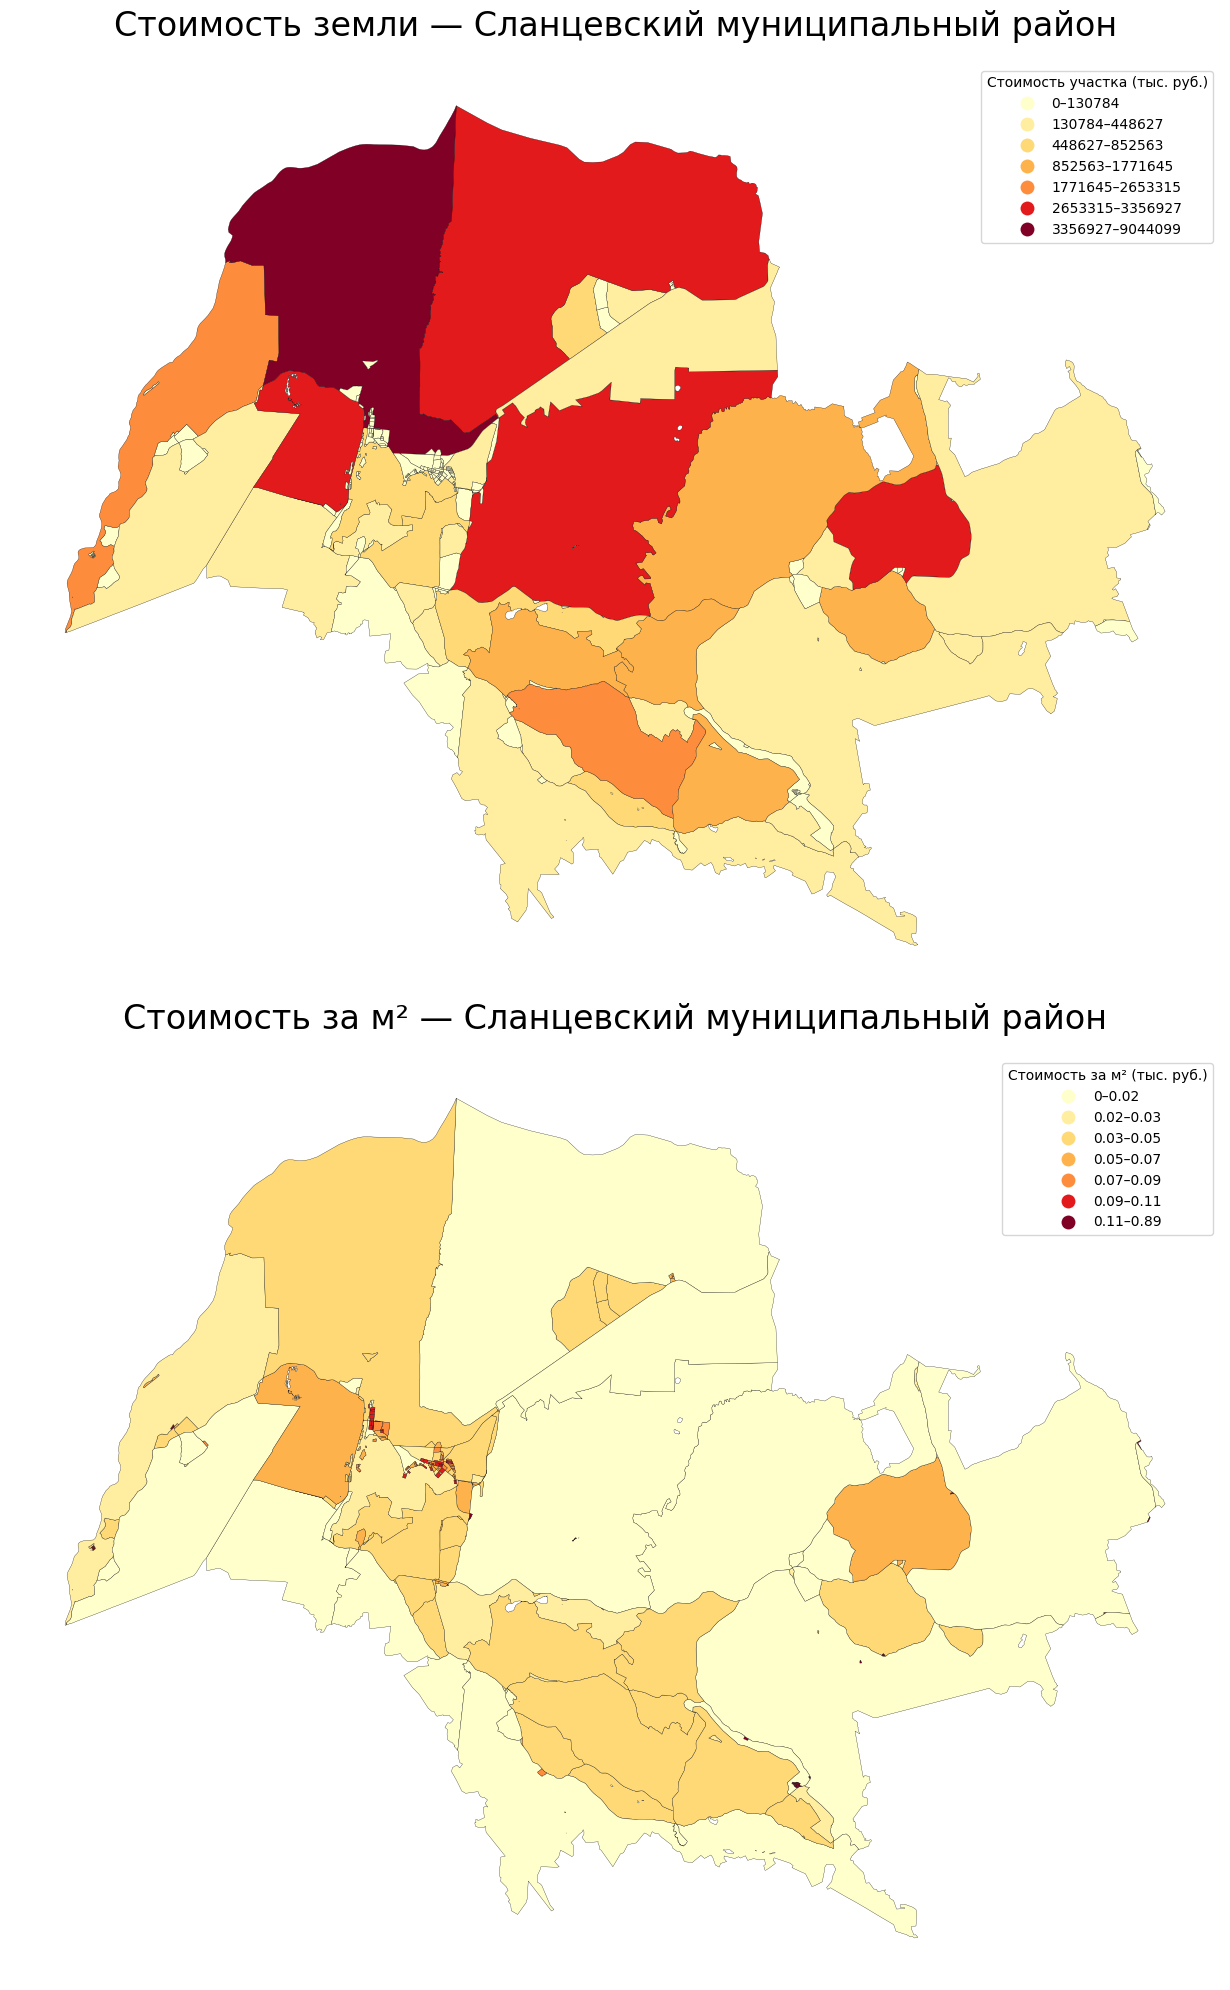

In [18]:
# Подготовка
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import matplotlib.colors as mcolors
import mapclassify

# Фильтрация по району
parent_name = filtered_gdf['parent_name'].iloc[0]

# Цветовая палитра
colors = ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#e31a1c', '#800026']
cmap = mcolors.ListedColormap(colors)

# --- 1. Визуализация по стоимости участка ---
# Jenks Natural Breaks для стоимости участка
classifier1 = mapclassify.NaturalBreaks(filtered_gdf['Стоимость участка (тыс. руб.)'], k=7)
bin_edges1 = classifier1.bins
bin_labels1 = [f"{int(bin_edges1[i-1]) if i > 0 else 0}–{int(b)}" for i, b in enumerate(bin_edges1)]

filtered_gdf['Категория_стоимости_участка'] = pd.cut(
    filtered_gdf['Стоимость участка (тыс. руб.)'],
    bins=[0] + list(bin_edges1),
    labels=bin_labels1,
    include_lowest=True
)

# --- 2. Визуализация по стоимости за квадратный метр ---
# Jenks Natural Breaks для стоимости за м²
classifier2 = mapclassify.NaturalBreaks(filtered_gdf['Стоимость за м² (тыс. руб.)'], k=7)
bin_edges2 = classifier2.bins
bin_labels2 = [f"{round(bin_edges2[i-1], 2) if i > 0 else 0}–{round(b, 2)}" for i, b in enumerate(bin_edges2)]

filtered_gdf['Категория_стоимости_за_м2'] = pd.cut(
    filtered_gdf['Стоимость за м² (тыс. руб.)'],
    bins=[0] + list(bin_edges2),
    labels=bin_labels2,
    include_lowest=True
)

# --- Построение карт ---
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

# Карта 1 — Стоимость участка
filtered_gdf.plot(
    column='Категория_стоимости_участка',
    cmap=cmap,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "Стоимость участка (тыс. руб.)"},
    ax=axes[0]
)
axes[0].set_title(f'Стоимость земли — {parent_name}', fontsize=24, pad=20)
axes[0].axis('off')

# Карта 2 — Стоимость за квадратный метр
filtered_gdf.plot(
    column='Категория_стоимости_за_м2',
    cmap=cmap,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "Стоимость за м² (тыс. руб.)"},
    ax=axes[1]
)
axes[1].set_title(f'Стоимость за м² — {parent_name}', fontsize=24, pad=20)
axes[1].axis('off')

plt.tight_layout()
plt.show()


# Предсказание стоимости